# 📊 Prévision des Charges d'Impression — Yazaki 2026
### Charges d'Impression mensuellle par Département ·


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# holt-winters
from statsmodels.tsa.holtwinters   import ExponentialSmoothing
# SARIMA
from pmdarima                      import auto_arima
# métriques d'évaluation des modeles
from sklearn.metrics               import mean_absolute_error, mean_squared_error

print("OK - Librairies importees")

OK - Librairies importees


## 2. Chargement des données

In [2]:
from pathlib import Path
import os ,sys

project_root = Path(Path.cwd())
if not (project_root / 'etl').exists():
    parent = Path.cwd().parent
    if (parent / 'etl').exists():
        project_root = parent

# Ajouter le projet au chemin de recherche Python
sys.path.insert(0, str(project_root))

from etl.config import get_clean_engine

with get_clean_engine().connect() as conn:
    charges_imp = pd.read_sql("SELECT * FROM ChargesImpression", conn)

print(f"OK - Project root : {project_root}")
print(f"OK - ChargesImpression chargees depuis Yazaki_Clean : {len(charges_imp):,} lignes")
print(charges_imp.head(3))

OK - Project root : c:\Users\habib\Desktop\Yazaki\ETL-Yazaki
OK - ChargesImpression chargees depuis Yazaki_Clean : 9,591 lignes
   ImpressionID NomDepartement CodeDepartement DateImpression TypeImpression  \
0         10560        FINANCE             FIN     2023-01-15          A4-NB   
1         10561        FINANCE             FIN     2023-02-20          A4-NB   
2         10562        FINANCE             FIN     2023-05-18     A4-COULEUR   

   NbPages  CoutUnitaire FormatPapier CouleurImpression  
0      190         0.026           A4     NOIR ET BLANC  
1       90         0.026           A4     NOIR ET BLANC  
2      260         0.156           A4           COULEUR  


## 3. Préparation des séries mensuelles par département

In [3]:
charges_imp['DateImpression'] = pd.to_datetime(charges_imp['DateImpression'])
charges_imp['NomDepartement'] = charges_imp['NomDepartement'].astype(str).str.strip()
charges_imp = charges_imp[charges_imp['NomDepartement'].str.upper() != 'INCONNU']
charges_imp['CoutImp'] = charges_imp['NbPages'] * charges_imp['CoutUnitaire']

imp_par_dept = (
    charges_imp
    .assign(Mois=charges_imp['DateImpression'].dt.to_period('M'))
    .groupby(['Mois', 'NomDepartement'])['CoutImp']
    .sum().unstack(fill_value=0).astype(float)
    # unstack pour avoir les departements en colonnes et les mois en index, fill_value=0 pour les mois sans impression
)
imp_par_dept.index = imp_par_dept.index.to_timestamp() # convertir les index de période en timestamps pour faciliter la manipulation temporelle

print(f"OK - {imp_par_dept.shape[1]} departements | {len(imp_par_dept)} mois")
print(f"     {imp_par_dept.index[0].date()} -> {imp_par_dept.index[-1].date()}")
print(f"\nDepartements : {sorted(imp_par_dept.columns.tolist())}")

OK - 16 departements | 41 mois
     2023-01-01 -> 2026-05-01

Departements : ['ACHAT', 'COSEE', 'DIRECTION', 'EHS', 'ENGENIERIE', 'FINANCE', 'IT', 'LOGISTIQUE', 'NYS', 'OLS', 'PLPP', 'PRODUCTION A', 'PRODUCTION B', 'QUALITE', 'RH', 'TD']


## 4. Visualisation exploratoire

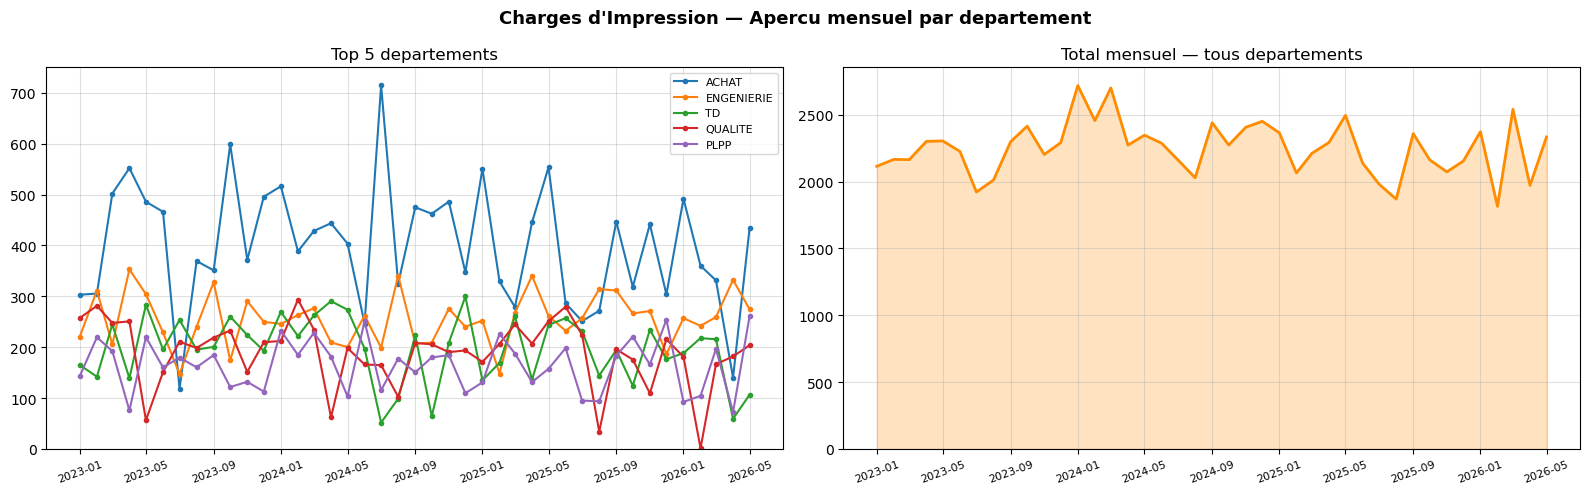

OK - viz_exploratoire_impression.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Charges d'Impression — Apercu mensuel par departement", fontsize=13, fontweight='bold')

# Top 5 departements
top5 = imp_par_dept.sum().nlargest(5).index # index contient les noms des 5 departements avec le plus de charges d'impression
for dept in top5:
    axes[0].plot(imp_par_dept.index, imp_par_dept[dept], marker='o', markersize=3, label=dept)
axes[0].set_title("Top 5 departements")
axes[0].legend(fontsize=8); axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.4); axes[0].tick_params(axis='x', rotation=20, labelsize=8)

# Total mensuel
total = imp_par_dept.sum(axis=1)
axes[1].fill_between(total.index, total.values, alpha=0.25, color='darkorange')
axes[1].plot(total.index, total.values, color='darkorange', linewidth=2)
axes[1].set_title("Total mensuel — tous departements")
axes[1].set_ylim(bottom=0); axes[1].grid(True, alpha=0.4)
axes[1].tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout() # pour eviter que les titres et axes ne se chevauchent
plt.savefig('viz_exploratoire_impression.png', dpi=120, bbox_inches='tight')
# bbox_inches() pour s'assurer que tout le contenu du graphique est inclus dans l'image, même les titres et les étiquettes d'axes
plt.show()
print("OK - viz_exploratoire_impression.png")

## 5. Modèles de prévision : SARIMA + HW

| Modèle | Librairie |
|---|---|
| **SARIMA** | pmdarima |
| **Holt-Winters** | statsmodels |
**************************************************
| Période | Dates |
|---|---|
| Entraînement | 2023-01 → 2024-12 |
| Test | 2025-01 → 2025-12 (12 mois — 1 cycle saisonnier complet) |
| Prévision | 2026-01 → 2026-12 |

**Sélection** : meilleur RMSE sur la période test (2025-01 → 2025-12)

**Fix appliqué** : Détection des prévisions constantes + basculement vers HW


### Paramètres globaux 

In [5]:
# Définition des périodes d'entraînement, de test et de prévision

TRAIN_START    = pd.Timestamp('2023-01-01')
TRAIN_END      = pd.Timestamp('2024-12-31')  # entraînement : 24 mois
TEST_START     = pd.Timestamp('2025-01-01')
TEST_END       = pd.Timestamp('2025-12-31')  # test : 12 mois = 1 cycle
FORECAST_START = pd.Timestamp('2026-01-01')
FORECAST_END   = pd.Timestamp('2026-12-31')

N_TEST       = 12   # 1 cycle saisonnier complet pour une évaluation fiable
N_FORECAST   = 12   # prévision sur toute l'année 2026


### Étape 1 — Entraînement & prédiction (`entrainer_predire`)

In [6]:
# ═══════════════════════════════════════════════════════════════
# ENTRAINER + PREDIRE
# ═══════════════════════════════════════════════════════════════
def entrainer_predire(mtype, y_train, n_steps):

    try:
        # -----------------------------------------------------------
        # 1. HOLT-WINTERS
        # -----------------------------------------------------------
        if mtype == 'hw':
            model = ExponentialSmoothing(
                y_train,
                trend='add',
                seasonal='add',
                seasonal_periods=12,
                initialization_method='estimated' # pour estimer les conditions initiales du modèle à partir des données d'entraînement
            ).fit(optimized=True)
            forecast = np.clip(model.forecast(n_steps), 0, None)
            return forecast, model   # ← retourne le modèle 

        # -----------------------------------------------------------
        # 2. SARIMA 
        # -----------------------------------------------------------
        elif mtype == 'sarima':
            model = auto_arima(
                y_train,
                seasonal=True,
                m=12,
                stepwise=True, # pour accélérer la recherche de l'ordre optimal en testant moins de combinaisons
                suppress_warnings=True, 
                error_action='ignore',
                max_p=5, max_q=5,
                max_P=3, max_Q=3,
                d=None,
                max_D=2,
                information_criterion='aic',
                with_intercept=True, # puisque les données ne sont pas centrées, on autorise un terme d'interception dans le modèle
                trace=False # pour afficher les résultats de chaque modèle testé (utile pour le debug, à désactiver pour la version finale)
            )

            forecast = np.clip(model.predict(n_periods=n_steps), 0, None)

            # Détection prévisions constantes ou quasi-constantes
            if len(np.unique(forecast)) <= 1: 
                return None
            mean_fc = np.mean(forecast)
            if mean_fc > 0:
                cv = np.std(forecast) / mean_fc
                if cv < 0.02:   # <2% variation → fallback vers HW
                    return None

            return forecast, model   # ← retourne le modèle 

    except:
        return None


### Étape 2 — Pipeline principal (`prevoir_departement`)

In [7]:
# ═══════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════
def prevoir_departement(nom_dept, y_full, dates_full,
                        n_forecast=N_FORECAST, n_test=N_TEST):

    y_train = y_full[:-n_test]
    y_test  = y_full[-n_test:]

    modeles = ['sarima', 'hw']

    # ── Évaluation de chaque candidat sur la période test ────────
    scores = {}
    for mtype in modeles:
        result = entrainer_predire(mtype, y_train, n_test)
        if result is not None:
            pred , modeles = result
            rmse = np.sqrt(mean_squared_error(y_test, pred))
            scores[mtype] = {'rmse': rmse, 'pred': pred}

    if not scores:
        print(f"  ⚠️ [{nom_dept}] aucun modèle n'a convergé — ignoré")
        return None

    # Choisir le modèle avec le RMSE le plus faible
    meilleur  = min(scores, key=lambda m: scores[m]['rmse']) # retourne la clé du modèle avec le RMSE le plus bas
    pred_test = scores[meilleur]['pred']

    print(f"    Evaluation test (n={n_test}) :")
    for m, s in sorted(scores.items(), key=lambda x: x[1]['rmse']):
        tag        = '  <-- CHOISI' if m == meilleur else ''
        print(f"      {m:<10} RMSE={s['rmse']:8.2f}{tag}")

    # ── Métriques finales ─────────────────────────────────────────
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
    mae_test  = mean_absolute_error(y_test, pred_test)
    denom     = np.where(np.abs(y_test) + np.abs(pred_test) == 0, 1,
                         np.abs(y_test) + np.abs(pred_test))
    smape_test = 2 * np.mean(np.abs(y_test - pred_test) / denom) * 100

    # ── Forecast final — entraîner sur y_full ────────────────────
    result_final = entrainer_predire(meilleur, y_full, n_forecast)

    if result_final is None:
        # SARIMA constant sur y_full → bascule vers HW
        print(f"    ⚠️ [{nom_dept}] {meilleur} CONSTANT sur y_full → HW")
        meilleur     = 'hw'
        result_final = entrainer_predire('hw', y_full, n_forecast)

    if result_final is None:
        # Cas extrême : HW aussi en échec
        print(f"    ⚠️ [{nom_dept}] HW aussi en échec → moyenne des 12 derniers mois")
        forecast    = np.full(n_forecast, np.mean(y_full[-12:]))
        final_model = None
    else:
        forecast, final_model = result_final   # ← modèle entraîné sur y_full

    future_dates = pd.date_range(
        start=dates_full[-1] + pd.DateOffset(months=1),
        periods=n_forecast, freq='MS')


    print(f"  OK [{nom_dept:<16}]  {meilleur:<10}  "
          f"RMSE={rmse_test:.2f}  MAE={mae_test:.2f}  sMAPE={smape_test:.1f}%")

    return {
        'dept'        : nom_dept,
        'modele'      : meilleur,
        'rmse'        : rmse_test,
        'mae'         : mae_test,
        'smape'       : smape_test,
        'forecast'    : forecast,
        'future_dates': future_dates,
        'pred_test'   : pred_test,
        'y_test'      : y_test,
        'dates'       : dates_full,
        'y'           : y_full,
    }

print("OK - Pipeline charge")
print("  Modeles   : SARIMA + Holt-Winters")
print("  Selection : RMSE min sur 12 mois de test (2025-01 → 2025-12)")
print("  Forecast  : 2026-01 → 2026-12 (12 mois)")


OK - Pipeline charge
  Modeles   : SARIMA + Holt-Winters
  Selection : RMSE min sur 12 mois de test (2025-01 → 2025-12)
  Forecast  : 2026-01 → 2026-12 (12 mois)


## 6. Lancer les prévisions

In [8]:
print("=" * 65)
print("  CHARGES IMPRESSION — Prevision par departement")
print("=" * 65)

resultats_imp = {}
for dept in imp_par_dept.columns:
    serie = imp_par_dept[dept].astype(float).loc[
        (imp_par_dept.index >= TRAIN_START) & (imp_par_dept.index <= TEST_END)
    ]
    if len(serie) <= N_TEST:
        print(f"  [{dept}] serie trop courte — ignoree")
        continue
    r = prevoir_departement(dept, serie.values, serie.index,
                            n_forecast=N_FORECAST, n_test=N_TEST)
    if r:
        resultats_imp[dept] = r

print(f"\n  => {len(resultats_imp)} departement(s) traite(s)")

  CHARGES IMPRESSION — Prevision par departement
    Evaluation test (n=12) :
      sarima     RMSE=  136.34  <-- CHOISI
      hw         RMSE=  139.70
  OK [ACHAT           ]  sarima      RMSE=136.34  MAE=116.47  sMAPE=29.0%
    Evaluation test (n=12) :
      hw         RMSE=   43.16  <-- CHOISI
  OK [COSEE           ]  hw          RMSE=43.16  MAE=34.93  sMAPE=35.5%
    Evaluation test (n=12) :
      hw         RMSE=   17.80  <-- CHOISI
  OK [DIRECTION       ]  hw          RMSE=17.80  MAE=13.51  sMAPE=24.9%
    Evaluation test (n=12) :
      hw         RMSE=   24.55  <-- CHOISI
  OK [EHS             ]  hw          RMSE=24.55  MAE=19.25  sMAPE=42.2%
    Evaluation test (n=12) :
      hw         RMSE=   64.24  <-- CHOISI
  OK [ENGENIERIE      ]  hw          RMSE=64.24  MAE=53.16  sMAPE=22.7%
    Evaluation test (n=12) :
      hw         RMSE=  166.67  <-- CHOISI
  OK [FINANCE         ]  hw          RMSE=166.67  MAE=152.38  sMAPE=121.4%
    Evaluation test (n=12) :
      hw         RMSE=

In [9]:
# Correctif FINANCE : série trop erratique pour HW ou SARIMA
# → remplacement par la moyenne des 12 derniers mois
if 'FINANCE' in resultats_imp:
    r = resultats_imp['FINANCE']
    moy_12 = np.mean(r['y'][-12:]) # r['y'] contient la série complète (train + test), on prend les 12 derniers mois de cette série pour calculer la moyenne, ce qui correspond à la moyenne des 12 derniers mois de la période test (2025) et d'une partie de la période d'entraînement (2024), ce qui est plus représentatif que de prendre les 12 derniers mois de l'entraînement seul
    r['forecast'] = np.full(N_FORECAST, round(moy_12, 2))
    r['modele']   = 'mean_12m'
    print(f"  [FINANCE] forecast remplacé par moyenne 12 derniers mois : {moy_12:.2f} TND/mois")

  [FINANCE] forecast remplacé par moyenne 12 derniers mois : 59.55 TND/mois


## 7. Tableau des performances

In [10]:
def tableau_performances(resultats, label):
    print(f"\n{'='*70}")
    print(f"  {label} — Résumé global (trié par RMSE)")
    print(f"{'='*70}")
    rows = [{
        'Departement'   : dept,
        'Modele'        : r['modele'], 
        'RMSE'          : round(r['rmse'], 2),
        'MAE'           : round(r['mae'],  2),
        'sMAPE%'        : round(r['smape'], 1),
    } for dept, r in resultats.items()]
    df = pd.DataFrame(rows).set_index('Departement').sort_values('RMSE')
    print(df.to_string())
    print(f"\n  RMSE moyen : {df['RMSE'].mean():.1f}")

recap_imp = tableau_performances(resultats_imp, "Charges Impression")



  Charges Impression — Résumé global (trié par RMSE)
                Modele    RMSE     MAE  sMAPE%
Departement                                   
DIRECTION           hw   17.80   13.51    24.9
EHS                 hw   24.55   19.25    42.2
PRODUCTION A        hw   26.24   21.20    33.6
LOGISTIQUE          hw   28.64   24.11    18.7
PRODUCTION B        hw   33.44   28.51    17.9
RH                  hw   35.72   28.84    20.3
COSEE               hw   43.16   34.93    35.5
PLPP            sarima   49.83   42.19    25.7
TD                  hw   49.99   40.57    21.2
IT                  hw   55.59   47.85    93.5
OLS                 hw   59.01   50.99    39.8
NYS                 hw   61.91   49.29    65.6
ENGENIERIE          hw   64.24   53.16    22.7
QUALITE             hw   77.73   63.00    39.4
ACHAT           sarima  136.34  116.47    29.0
FINANCE       mean_12m  166.67  152.38   121.4

  RMSE moyen : 58.2


## 8. Visualisations avancées — Réel vs Prévisions

In [11]:
def comparaison_reel_prevision(resultats, label, c_reel, c_prev, out_dir, top_n=5):
    os.makedirs(out_dir, exist_ok=True)
    depts = sorted(resultats.keys())
    
    # Garder seulement les top N départements par sMAPE (meilleure performance)
    if top_n is not None and len(depts) > top_n:
        depts = sorted(depts, key=lambda d: resultats[d]['rmse'])[:top_n]
        depts = sorted(depts)  # Re-trier alphabétiquement

    for dept in depts:
        r = resultats[dept]

        fig, ax = plt.subplots(1, 1, figsize=(14, 6))
        fig.suptitle(f'{label} — {dept}\n{r["modele"]} | RMSE={r["rmse"]:.1f}',
                     fontsize=13, fontweight='bold')

        # ── Découpage des périodes ──────────────────────────────
        n_test      = len(r['y_test'])
        n_train     = len(r['y']) - n_test
        dates_all   = pd.DatetimeIndex(r['dates'])
        dates_hist  = dates_all[:n_train] 
        dates_test  = dates_all[n_train:] 

        # ── Zone historique  ─────────────────────
        ax.plot(dates_hist, r['y'][:n_train],
                color=c_reel, linewidth=2.0, label='Historique (réel)', zorder=3)


        # ── Zone test : réel vs prédit ───────────────────────────
        ax.plot(dates_test, r['y_test'],
                color=c_reel, linewidth=2.0, marker='o', markersize=6,
                linestyle='-', zorder=4)   # continuation de la courbe réelle
        ax.plot(dates_test, r['pred_test'],
                color=c_prev, linewidth=2.0, marker='s', markersize=6,
                linestyle='--', label='Prédit (test)', zorder=4)

        # ── Zone forecast ────────────────────────────────────────
        ax.plot(r['future_dates'], r['forecast'],
                color=c_prev, linewidth=2.5, marker='D', markersize=5,
                linestyle='-', alpha=0.75,
                label=f'Forecast ({len(r["forecast"])}m)', zorder=4)
        ax.fill_between(r['future_dates'], 0, r['forecast'],
                        color=c_prev, alpha=0.10)
        
        # ── Lignes de séparation entre zones ────────────────────
        ax.axvline(dates_test[0],       color='gray',  linestyle=':', linewidth=1.5, alpha=0.7)
        ax.axvline(r['future_dates'][0],color=c_prev,  linestyle=':', linewidth=1.5, alpha=0.7)

        # ── Annotations des zones ────────────────────────────────
        ax.text(dates_hist[len(dates_hist)//2], ax.get_ylim()[1] * 0.97,
                'Historique', ha='center', va='top', fontsize=8, color='gray')
        ax.text(dates_test[len(dates_test)//2], ax.get_ylim()[1] * 0.97,
                'Test', ha='center', va='top', fontsize=8, color='gray')
        ax.text(r['future_dates'][len(r['future_dates'])//2], ax.get_ylim()[1] * 0.97,
                'Prévision', ha='center', va='top', fontsize=8, color=c_prev)

        ax.set_ylabel('Charge (TND)', fontsize=11)
        ax.set_xlabel('Mois', fontsize=11)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.25, axis='y')
        ax.legend(fontsize=9, loc='upper left')
        ax.tick_params(axis='x', rotation=30, labelsize=8)

        plt.tight_layout()

        dept_clean = dept.replace(' ', '_').replace('/', '_')
        path = os.path.join(out_dir, f'reel_vs_previsions_{dept_clean}.png')
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.close()
        print(f"OK - {path}")

comparaison_reel_prevision(resultats_imp, "Charges Impression",
                           c_reel='darkorange', c_prev='#7c3aed',
                           out_dir='previsions_imp')

OK - previsions_imp\reel_vs_previsions_DIRECTION.png
OK - previsions_imp\reel_vs_previsions_EHS.png
OK - previsions_imp\reel_vs_previsions_LOGISTIQUE.png
OK - previsions_imp\reel_vs_previsions_PRODUCTION_A.png
OK - previsions_imp\reel_vs_previsions_PRODUCTION_B.png


## 9. Enregistrement SQL Server

In [12]:
from sqlalchemy import text
from etl.config import get_dw_engine

def sauvegarder_previsions_sql(resultats, charge_type, date_min=TRAIN_START, date_max=FORECAST_END):
    engine = get_dw_engine()
    rows   = []
    test_dates = pd.date_range(start=TEST_START, end=TEST_END, freq='MS') 

    for dept, r in resultats.items(): # zip pour itérer simultanément sur les départements et leurs résultats
        for d, v in zip(r['dates'], r['y']):
            rows.append({'NomDepartement': dept, 'Mois': pd.to_datetime(d).date(),
                         'Type': 'Historique', 'ChargeType': charge_type,
                         'ChargeValue': round(float(v), 2), 'Modele': None})

        for d, v in zip(test_dates, r['pred_test']):
            rows.append({'NomDepartement': dept, 'Mois': pd.to_datetime(d).date(),
                         'Type': 'Prevision', 'ChargeType': charge_type,
                         'ChargeValue': round(float(v), 2), 'Modele': str(r.get('modele', ''))})

        for d, v in zip(r['future_dates'], r['forecast']):
            rows.append({'NomDepartement': dept, 'Mois': pd.to_datetime(d).date(),
                         'Type': 'Prevision', 'ChargeType': charge_type,
                         'ChargeValue': round(float(v), 2), 'Modele': str(r.get('modele', ''))})

    if not rows:
        print(f"Aucune ligne a inserer pour {charge_type}")
        return 0

    df_rows = pd.DataFrame(rows)
    with engine.begin() as conn:
        dim_dept = pd.read_sql("SELECT DepartementID, NomDepartement FROM Dim_Departement", conn)
        dept_map = dict(zip(dim_dept['NomDepartement'], dim_dept['DepartementID']))
        df_rows['DepartementID'] = df_rows['NomDepartement'].map(dept_map)

        manquants = sorted(df_rows[df_rows['DepartementID'].isna()]['NomDepartement'].unique().tolist())
        if manquants:
            print(f"Departements absents dans Dim_Departement (ignores) : {manquants}")

        df_rows = df_rows.dropna(subset=['DepartementID']).copy()
        if df_rows.empty:
            print(f"Aucune ligne valide pour {charge_type}")
            return 0

        conn.execute(text("""
            DELETE FROM Previsions
            WHERE ChargeType = :charge_type
              AND Mois BETWEEN :date_min AND :date_max
        """), {'charge_type': charge_type,
                 'date_min': pd.to_datetime(date_min).date(),
                 'date_max': pd.to_datetime(date_max).date()})

        payload = [{'DepartementID': int(row.DepartementID), 'Mois': row.Mois,
                    'Type': row.Type, 'ChargeType': row.ChargeType,
                    'ChargeValue': float(row.ChargeValue),
                    'Modele': (None if pd.isna(row.Modele) or row.Modele == ''
                               else str(row.Modele))}
                   for row in df_rows.itertuples(index=False)]

        conn.execute(text("""
            INSERT INTO Previsions (DepartementID, Mois, Type, ChargeType, ChargeValue, Modele)
            VALUES (:DepartementID, :Mois, :Type, :ChargeType, :ChargeValue, :Modele)
        """), payload)

    print(f"OK - {len(payload)} ligne(s) inseree(s) dans Previsions pour {charge_type}")
    return len(payload)


### Lancement de l'enregistrement SQL

In [13]:
print("=" * 65)
print("  ENREGISTREMENT SQL SERVER — TABLE Previsions")
print("=" * 65)
n_imp = sauvegarder_previsions_sql(resultats_imp, 'Impression')
print(f"Total insere : {n_imp} ligne(s)")

  ENREGISTREMENT SQL SERVER — TABLE Previsions
OK - 960 ligne(s) inseree(s) dans Previsions pour Impression
Total insere : 960 ligne(s)
